In [1]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision import transforms
from PIL import Image
import cv2
import matplotlib.pyplot as plt 



In [2]:
model=fasterrcnn_resnet50_fpn(weights='DEFAULT')
model.eval()
transform=transforms.Compose([transforms.ToTensor()])

<function matplotlib.pyplot.show(close=None, block=None)>

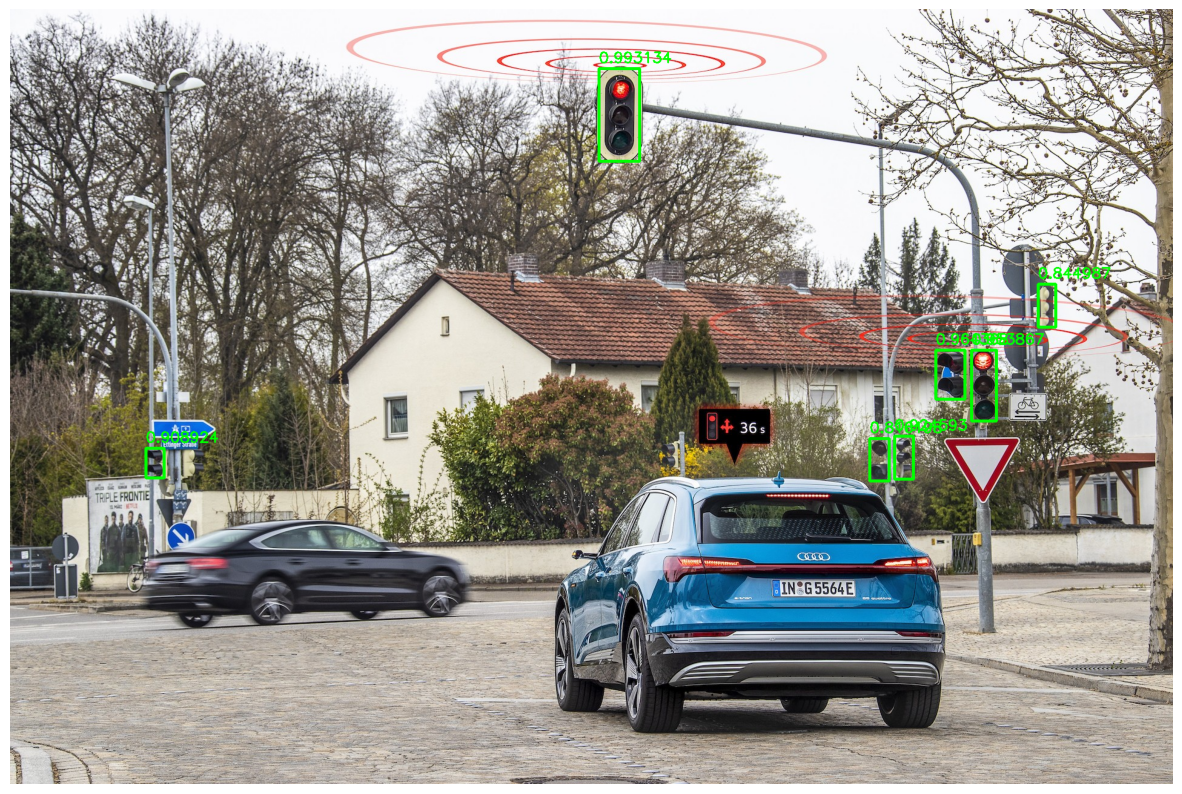

In [3]:
def detect_frcnn(image_path,threshold=0.8):
    img=Image.open(image_path).convert("RGB")
    img_t=transform(img)
    with torch.no_grad():
        outputs=model([img_t])[0]
    img_cv=cv2.imread(image_path) 
    for box , score , label in zip(outputs['boxes'],outputs['scores'] , outputs['labels']):
     if score > threshold and label==10:
        x1,y1,x2,y2=map(int,box.tolist())
        cv2.rectangle(img_cv,(x1,y1), (x2,y2) , (0,255,0),3)
        cv2.putText(img_cv,f"{score:2f}",(x1,y1-10),
        cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,0.8,(0,255,0),2)
    return img_cv
if __name__=="__main__":
        img_path = r"C:\Users\Mazen\Downloads\AMIT\traffic.jpg.jpg"
        result=detect_frcnn(img_path)
        result_rgb=cv2.cvtColor(result,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15,15))
plt.imshow(result_rgb)
plt.axis("off")
plt.show


# YOLO

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


image 1/1 C:\Users\Mazen\Downloads\AMIT\traffic.jpg.jpg: 448x640 4 traffic lights, 44.4ms
Speed: 1.7ms preprocess, 44.4ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


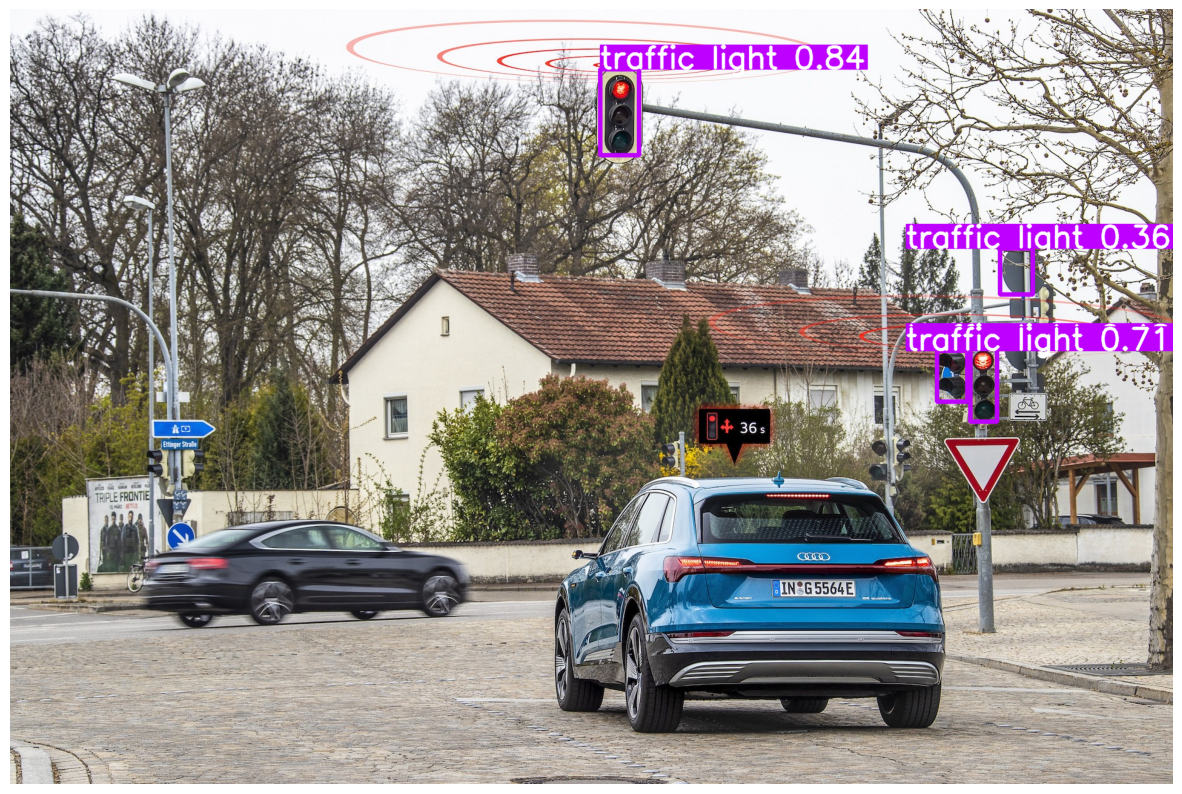

In [6]:
model=YOLO("yolov8n.pt")
def detect_yolo(image_path):
    results=model(image_path,classes=[9])
    img=results[0].plot()
    return img
if __name__=="__main__":
    img_path= r"C:\Users\Mazen\Downloads\AMIT\traffic.jpg.jpg"
    result=detect_yolo(img_path)
    result_rgb=cv2.cvtColor(result,cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15,15))
    plt.imshow(result_rgb) 
    plt.axis("off")
    plt.show()


# SEGMENTATION

In [8]:
import torch 
import torchvision.transforms as T 
from torchvision.models.segmentation import deeplabv3_resnet101
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

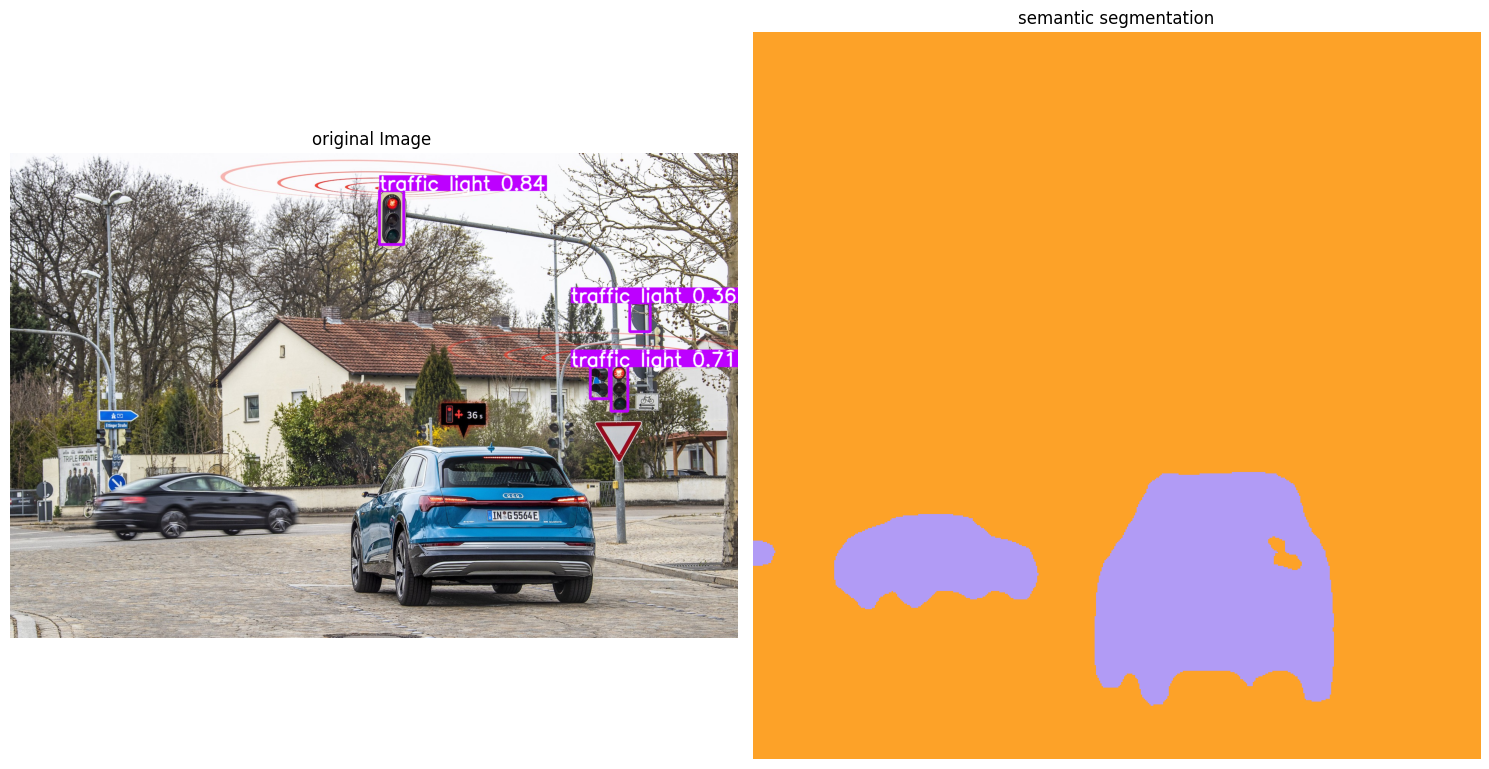

In [12]:
model=deeplabv3_resnet101(pretrained=True).eval()
img_path= r"C:\Users\Mazen\Downloads\AMIT\traffic.jpg.jpg"
img=cv2.imread(img_path)
img_rgb=cv2.cvtColor(result,cv2.COLOR_BGR2RGB)

transform=T.Compose([
    T.ToPILImage(),
    T.Resize((520,520)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
input_tensor=transform(img_rgb).unsqueeze(0)
with torch.no_grad():
    output=model(input_tensor)['out'][0]
    seg_mask=output.argmax(0).byte().cpu().numpy()
colors=np.random.randint(0,255,(21,3),dtype=np.uint8)
seg_color=colors[seg_mask]


plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("original Image ")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(seg_color)
plt.title("semantic segmentation")
plt.axis("off")
plt.tight_layout()
plt.show()
